# 13 · Seasonal analysis and economics

Compare Gainesville soybean management over ten generated-weather seasons using grain yield and net return at fixed expected prices.

## You will learn

- Run treatment 1 and three management scenarios over ten seasons.
- Compare seasonal grain yield with summary statistics and a box plot.
- Calculate net returns and describe their mean and weather-driven variation.

In [1]:
LESSON = "13_seasonal_economics"

In [2]:
# Connect to DSSAT and prepare a fresh copy of the lesson's data.
import os, shutil, subprocess, sys
from pathlib import Path
if "google.colab" in sys.modules:
    subprocess.run([sys.executable, "-m", "pip", "install", "dssatlab[course]>=0.23,<0.24"], check=True, capture_output=True)
    if Path.cwd().name != LESSON:
        if not Path("dssatlab").exists():
            subprocess.run(["git", "clone", "--depth", "1", "https://github.com/AbdelrahmanAmr3/dssatlab"], check=True)
        os.chdir(Path("dssatlab") / "course" / LESSON)
import dssatlab as dl
if "google.colab" in sys.modules:
    dl.install()
dssat = dl.connect()
HERE = Path.cwd()
RUNS = HERE / "runs"
if RUNS.exists():
    shutil.rmtree(RUNS)
_ = shutil.copytree(HERE / "data", RUNS)

Load tools for tables and inline plots.

In [3]:
# Load the lesson tools.
import matplotlib.pyplot as plt
%matplotlib inline
print("Tools ready: tables and plots.")

Tools ready: tables and plots.


Select the copied inputs and check ten WGEN seasons with the same random seed.

In [4]:
# Prepare and check the seasonal base Simulation.
inputs = {
    "filex": RUNS / "UFGA7901.SBX",
    "weather": RUNS / "UFGA.CLI",
    "soil": RUNS / "SOIL.SOL",
    "executable": dssat,
}
price_file = RUNS / "DEFAULT.PRI"
controls = {"years": 10, "weather_source": "W", "random_seed": 1234}
experiment = {"treatments": {1: {"controls": controls}}}
sim = dl.Simulation(**inputs, treatment=1, management=experiment)
problems = sim.check(verbose=False)
print("Inputs:", ", ".join(inputs[key].relative_to(HERE).as_posix()
                          for key in ("filex", "weather", "soil"))
      + ", " + price_file.relative_to(HERE).as_posix())
print("Problems:", problems)

Inputs: runs/UFGA7901.SBX, runs/UFGA.CLI, runs/SOIL.SOL, runs/DEFAULT.PRI
Problems: []


🌱 Crop idea  
Stock treatment 1 grows Bragg soybean (`IB0001`) on soil profile `IBSB910015`, with nine scheduled irrigations totalling 113 mm per season.
Stock daily weather has only nine consecutive years from 1979; WGEN uses the stock Gainesville climate file to generate ten seasons, labelled 1979–1988, rather than replay those historical years.

Define rainfed and two automatic-irrigation scenarios while retaining treatment 1 for price matching.

In [5]:
# Define three complete management overrides and show their choices.
scenarios = {
    "Rainfed": {"management": {"treatments": {1: {
        "irrigation": [],
        "controls": dict(controls, irrigation_management="N"),
    }}}},
}
for threshold in (40, 70):
    scenarios[f"Auto {threshold}%"] = {"management": {"treatments": {1: {
        "irrigation": [],
        "controls": dict(controls, irrigation_management="A",
                         auto_irrigation_depth=30,
                         auto_irrigation_threshold=threshold,
                         auto_irrigation_refill=100,
                         auto_irrigation_method="IR001",
                         auto_irrigation_efficiency=0.75),
    }}}}
dl.to_dataframe([
    {"Option": "base", "Irrigation": "Stock schedule", "Seasons": 10},
    {"Option": "Rainfed", "Irrigation": "None", "Seasons": 10},
    {"Option": "Auto 40%", "Irrigation": "40% threshold, 30 cm depth", "Seasons": 10},
    {"Option": "Auto 70%", "Irrigation": "70% threshold, 30 cm depth", "Seasons": 10},
])

,Option,Irrigation,Seasons
0,base,Stock schedule,10
1,Rainfed,None,10
2,Auto 40%,"40% threshold, 30 cm depth",10
3,Auto 70%,"70% threshold, 30 cm depth",10


🐍 Python idea  
A scenario's management replaces the whole base management input, so each override repeats `controls` for ten seasons and seed 1234.
Automatic irrigation refills the top 30 cm to 100% available water at the chosen threshold; efficiency is 0.75, and `irrigation: []` removes scheduled events.

Run all four options and count the seasons returned by DSSAT.

In [6]:
# Run treatment 1 once per option across ten seasons.
results = dl.run_treatments(**inputs, treatments=[1], management=experiment,
                            scenarios=scenarios)
print("Seasons:", ", ".join(f"{name}: {len(result.summary())}"
                            for (name, treatment), result in results.items()))

Seasons: base: 10, Rainfed: 10, Auto 40%: 10, Auto 70%: 10


Combine the Summary rows to inspect grain yield (`HWAM`, kg/ha) and irrigation (`IRCM`, mm) by season.

In [7]:
# Display the first two seasons of each option.
rows = dl.combine_summaries(results)
season_table = dl.to_dataframe(rows)
season_table["Season"] = season_table["PDAT"].map(lambda day: day.year)
season_table.groupby("scenario", sort=False).head(2)[
    ["scenario", "TRNO", "Season", "HWAM", "IRCM"]
]

,scenario,TRNO,Season,HWAM,IRCM
0,base,1,1979,2336,113
1,base,1,1980,3468,113
10,Rainfed,1,1979,1888,0
11,Rainfed,1,1980,3211,0
20,Auto 40%,1,1979,3348,154
21,Auto 40%,1,1980,3470,102
30,Auto 70%,1,1979,3653,252
31,Auto 70%,1,1980,3569,199


Summarize all ten grain yields per option, including missing counts and sample standard deviation (`sd`, kg/ha).

In [8]:
# Compare the mean, spread and range of seasonal grain yield.
yield_stats = dl.to_dataframe(dl.summarize_seasons(rows, variables=["HWAM"]))
yield_stats[["scenario", "seasons", "missing", "mean", "sd", "min", "median", "max"]].round(1)

,scenario,seasons,missing,mean,sd,min,median,max
0,base,10,0,3125.6,495.0,2336,3173.0,3806
1,Rainfed,10,0,2710.0,781.6,1501,3085.0,3722
2,Auto 40%,10,0,3522.0,202.5,3191,3519.0,3876
3,Auto 70%,10,0,3713.8,123.1,3545,3708.5,3911


Plot each option's grain-yield distribution to see variation beyond the mean.

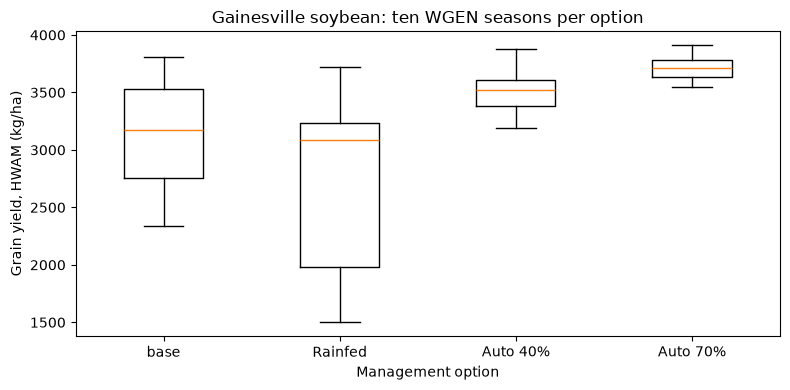

In [9]:
# Draw a box plot of grain yield for each option.
options = list(season_table["scenario"].drop_duplicates())
fig, ax = plt.subplots(figsize=(8, 4))
ax.boxplot([season_table.loc[season_table["scenario"] == option, "HWAM"]
            for option in options])
ax.set_xticks(range(1, len(options) + 1), options)
ax.set(xlabel="Management option", ylabel="Grain yield, HWAM (kg/ha)",
       title="Gainesville soybean: ten WGEN seasons per option")
plt.tight_layout()
plt.show()

🌱 Crop idea  
The box spans the middle half of yields, the line is the median, and points beyond the whiskers mark unusually distant values.
A fixed seed makes reruns reproducible; these ten generated seasons illustrate weather-driven variation, not the full range of possible outcomes.

Calculate each season's net return ($/ha) and inspect harvested yield (HWAH) and seed (DWAP) in kg/ha, N applied (NICM) in kg N/ha, irrigation (IRCM) in mm, and application counts (NI#M, IR#M).

In [10]:
# Calculate net returns and inspect the quantities used by the price file.
returns = dl.net_returns(rows, price_file)
return_table = dl.to_dataframe(returns)
return_table.groupby("scenario", sort=False).head(2)[
    ["scenario", "HWAH", "DWAP", "NICM", "NI#M", "IRCM", "IR#M", "net_return"]
].round(2)

,scenario,HWAH,DWAP,NICM,NI#M,IRCM,IR#M,net_return
0,base,2336,100,0,0,113,9,142.52
1,base,3468,100,0,0,113,9,504.76
10,Rainfed,1888,100,0,0,0,0,168.16
11,Rainfed,3211,100,0,0,0,0,591.52
20,Auto 40%,3348,100,0,0,154,9,445.86
21,Auto 40%,3470,100,0,0,102,6,548.40
30,Auto 70%,3653,100,0,0,252,21,344.46
31,Auto 70%,3569,100,0,0,199,17,394.08


🌱 Crop idea  
For soybean, [DEFAULT.PRI](data/DEFAULT.PRI) uses expected grain price $320/t, base cost $390/ha, seed cost $0.46/kg, and irrigation costs $0.50/mm plus $12.50/application.
`net_returns()` uses harvested yield `HWAH`, not `HWAM`, and includes every active price component; the file's price distributions are reduced to fixed expected values, with no price-risk sampling.

Summarize net return to compare average earnings and weather-driven variation at fixed prices.

In [11]:
# Compare net-return means, sample standard deviations and ranges.
return_stats = dl.to_dataframe(dl.summarize_seasons(returns, variables=["net_return"]))
return_stats[["scenario", "seasons", "missing", "mean", "sd", "min", "max"]].round(2)

,scenario,seasons,missing,mean,sd,min,max
0,base,10,0,395.19,158.41,142.52,612.92
1,Rainfed,10,0,431.20,250.11,44.32,755.04
2,Auto 40%,10,0,564.74,119.23,353.12,723.60
3,Auto 70%,10,0,434.07,85.87,300.78,558.52


🌱 Crop idea  
Auto 40% has mean net return $564.74/ha and sample standard deviation $119.23/ha, where risk means weather-driven variation at fixed expected prices.
Auto 70% has the highest mean grain yield but a lower mean net return ($434.07/ha); the first two seasons show more irrigation and applications, so yield alone does not rank net return.

## Your turn

Compare the stock irrigation schedule with your own automatic-irrigation threshold over ten seasons.

Hint: edit `chosen_threshold = 60` to another percentage from 0 to 100, then run this cell.

In [12]:
# Rebuild the comparison at your chosen irrigation threshold.
chosen_threshold = 60
exercise_inputs = {
    "filex": RUNS / "UFGA7901.SBX",
    "weather": RUNS / "UFGA.CLI",
    "soil": RUNS / "SOIL.SOL",
    "executable": dssat,
}
exercise_controls = {"years": 10, "weather_source": "W", "random_seed": 1234}
exercise_experiment = {"treatments": {1: {"controls": exercise_controls}}}
exercise_scenarios = {"Your irrigation": {"management": {"treatments": {1: {
    "irrigation": [],
    "controls": dict(exercise_controls, irrigation_management="A",
                     auto_irrigation_depth=30,
                     auto_irrigation_threshold=chosen_threshold,
                     auto_irrigation_refill=100,
                     auto_irrigation_method="IR001",
                     auto_irrigation_efficiency=0.75),
}}}}}
exercise_results = dl.run_treatments(**exercise_inputs, treatments=[1],
                                    management=exercise_experiment,
                                    scenarios=exercise_scenarios)
exercise_rows = dl.combine_summaries(exercise_results)
exercise_returns = dl.net_returns(exercise_rows, RUNS / "DEFAULT.PRI")
exercise_stats = dl.to_dataframe(dl.summarize_seasons(
    exercise_returns, variables=["HWAM", "IRCM", "net_return"]))
exercise_stats[["scenario", "variable", "seasons", "missing", "mean", "sd"]].round(2)

,scenario,variable,seasons,missing,mean,sd
0,base,HWAM,10,0,3125.60,495.03
1,base,IRCM,10,0,113.00,0.00
2,base,net_return,10,0,395.19,158.41
3,Your irrigation,HWAM,10,0,3673.60,150.85
4,Your irrigation,IRCM,10,0,169.90,48.17
5,Your irrigation,net_return,10,0,500.85,99.64


## Recap

- `controls.years` repeats a treatment over seasons; a fixed WGEN seed makes this example reproducible.
- `summarize_seasons()` and a box plot compare yield means, spread and missing values.
- `net_returns()` applies the price file to seasonal quantities; risk here is weather-driven variation at fixed expected prices.

Next: [14 · Crop rotations](../14_rotations/lesson.ipynb).